In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"dataset\BBC News Train.csv")
print(f'''
      Shape: {df.shape}
      Columns: {df.columns.tolist()}
      Category column values: {df['Category'].unique().tolist()}
''')


      Shape: (1490, 3)
      Columns: ['ArticleId', 'Text', 'Category']
      Category column values: ['business', 'tech', 'politics', 'sport', 'entertainment']



## Data filtering

In [3]:
tech_data = df[df.Category=='tech']
print(tech_data.shape)
tech_data.head()

(261, 3)


,ArticleId,Text,Category
3,1976,lifestyle governs mobile choice faster bett...,tech
19,1552,moving mobile improves golf swing a mobile pho...,tech
24,405,bt boosts its broadband packages british telec...,tech
26,702,peer-to-peer nets here to stay peer-to-peer ...,tech
30,1951,pompeii gets digital make-over the old-fashion...,tech


In [4]:
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
tech_data = tech_data.copy()

tech_data["num_sent"] = tech_data["Text"].apply(lambda x: len(sent_tokenize(x)))
filtered_data = tech_data[tech_data['Text'].str.contains('microsoft',case=False,na=False)]

filtered_data = filtered_data.copy()
filtered_data = filtered_data[(filtered_data["num_sent"] <= 15)]
filtered_data = filtered_data.drop_duplicates(subset=['Text'], keep='first')

filtered_data.to_csv(r'filtered_data.csv',index=False)

In [6]:
print(filtered_data.shape)
filtered_data.sort_values('num_sent')

(9, 4)


,ArticleId,Text,Category,num_sent
301,428,microsoft takes on desktop search microsoft ha...,tech,10
651,1615,microsoft seeking spyware trojan microsoft is ...,tech,10
428,69,microsoft gets the blogging bug software giant...,tech,13
509,2042,virus poses as christmas e-mail security firms...,tech,13
861,184,xbox power cable fire fear microsoft has sai...,tech,13
1179,728,anti-spam laws bite spammer hard the net s sel...,tech,13
48,277,halo 2 sells five million copies microsoft is ...,tech,14
589,1604,joke e-mail virus tricks users a virus that di...,tech,15
1305,1004,microsoft releases bumper patches microsoft ha...,tech,15


## Sentence Spliting

In [7]:
sentences = []
source_ids = []

for idx, row in filtered_data.iterrows():
    article_id = row["ArticleId"]
    text = row["Text"]
    
    sents = sent_tokenize(text)
    
    for s in sents:
        s = s.strip()
        if len(s) > 0:
            sentences.append(s)
            source_ids.append(article_id)

In [8]:
sent_df = pd.DataFrame({
    "article_id": source_ids,
    "sentence": sentences
})

In [9]:
print(sent_df.shape)
sent_df.head(20)

(116, 2)


,article_id,sentence
0,277,halo 2 sells five million copies microsoft is ...
1,277,halo 2 has proved popular online with gamers ...
2,277,according to microsoft nine out of 10 xbox li...
3,277,the sequel to the best-selling need for speed:...
4,277,the racing game moved up one spot to first pla...
5,277,halo 2 dropped one place to five while half-l...
6,277,last week s new releases goldeneye: rogue age...
7,277,record numbers of warcraft fans are settling i...
8,277,on the opening day of the world of warcraft ma...
9,277,on the evening of the first day more than 100 ...


## Sentence preprocessing

In [10]:
import re
import unicodedata

In [11]:
clean_sentences = []

for s in sent_df["sentence"]:
    original = s
    
    s = s.strip()
    
    if len(s.split()) < 5:
        continue
    
    if not re.search(r"[A-Za-z]", s):
        continue
    
    if len(re.sub(r"[A-Za-z0-9]", "", s)) / len(s) > 0.5:
        continue
    
    bad_patterns = [
        r"click here", r"share this", r"subscribe", r"read more",
        r"copyright", r"all rights reserved"
    ]
    if any(re.search(pat, s.lower()) for pat in bad_patterns):
        continue
    
    clean_sentences.append(s)

In [12]:

filtered_sent_df = pd.DataFrame({
    "article_id": source_ids,
    "sentence": clean_sentences
    })

print("Before:", sent_df.shape)
print("After:", filtered_sent_df.shape)

Before: (116, 2)
After: (116, 2)


In [13]:
filtered_sent_df.head()

,article_id,sentence
0,277,halo 2 sells five million copies microsoft is ...
1,277,halo 2 has proved popular online with gamers ...
2,277,according to microsoft nine out of 10 xbox li...
3,277,the sequel to the best-selling need for speed:...
4,277,the racing game moved up one spot to first pla...


In [14]:
def light_clean(text):
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[-_]{2,}', ' ', text)
    text = re.sub(r'([!?.,]){2,}', r'\1', text)
    text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != "C")
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    
    return text

In [15]:
df_sent = filtered_sent_df.copy()

df_sent["clean_sentence"] = df_sent["sentence"].astype(str).apply(light_clean)

In [16]:
before = df_sent.shape[0]
df_sent = df_sent[df_sent["clean_sentence"].str.strip() != ""].reset_index(drop=True)
after = df_sent.shape[0]

final_df = df_sent[["article_id", "clean_sentence"]].rename(columns={"clean_sentence": "sentence"})

In [17]:
print(f"Sentences before cleaning: {before}")
print(f"Sentences after cleaning & removing empties: {after}")

Sentences before cleaning: 116
Sentences after cleaning & removing empties: 116


In [18]:
final_df.head()

,article_id,sentence
0,277,halo 2 sells five million copies microsoft is ...
1,277,halo 2 has proved popular online with gamers n...
2,277,according to microsoft nine out of 10 xbox liv...
3,277,the sequel to the best-selling need for speed:...
4,277,the racing game moved up one spot to first pla...


## Sentence Embedings

In [19]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [21]:
MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 64 

model = SentenceTransformer(MODEL_NAME)

In [22]:
sentences = final_df["sentence"].astype(str).tolist()
print("Number of sentences to encode:", len(sentences))

Number of sentences to encode: 116


In [24]:
embeddings = model.encode(sentences,
                batch_size=BATCH_SIZE,
                show_progress_bar=True,
                convert_to_numpy=True
            )

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings shape: (116, 384)


In [28]:
sent_emb_df = final_df.reset_index(drop=True).copy()
sent_emb_df["emb_index"] = np.arange(len(sent_emb_df))

sent_emb_df.head()

,article_id,sentence,emb_index
0,277,halo 2 sells five million copies microsoft is ...,0
1,277,halo 2 has proved popular online with gamers n...,1
2,277,according to microsoft nine out of 10 xbox liv...,2
3,277,the sequel to the best-selling need for speed:...,3
4,277,the racing game moved up one spot to first pla...,4


## Dimensionality reduction

In [29]:
import umap

In [32]:
print("Original embedding shape:", embeddings.shape)

Original embedding shape: (116, 384)


In [35]:
n_components_cluster = 20   # You can adjust between 10 and 30
n_neighbors = 15            # Controls how local/global the structure is

In [36]:
umap_cluster = umap.UMAP(
    n_components=n_components_cluster,
    n_neighbors=n_neighbors,
    metric='cosine',
    random_state=42
)

emb_reduced = umap_cluster.fit_transform(embeddings)
print("Reduced embedding shape:", emb_reduced.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embedding shape: (116, 20)


In [37]:
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

emb_2d = umap_2d.fit_transform(embeddings)
print("2D embedding shape:", emb_2d.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embedding shape: (116, 2)


In [38]:
sent_emb_df["umap_x"] = emb_2d[:, 0]
sent_emb_df["umap_y"] = emb_2d[:, 1]

sent_emb_df.head()

,article_id,sentence,emb_index,umap_x,umap_y
0,277,halo 2 sells five million copies microsoft is ...,0,3.419658,5.107649
1,277,halo 2 has proved popular online with gamers n...,1,3.447265,5.453901
2,277,according to microsoft nine out of 10 xbox liv...,2,3.672795,5.414927
3,277,the sequel to the best-selling need for speed:...,3,2.938107,5.294118
4,277,the racing game moved up one spot to first pla...,4,3.241683,4.967222


## HDBSCAN Clustering

In [39]:
import hdbscan

In [40]:
MIN_CLUSTER_SIZE = 8    # minimum number of sentences to form a cluster (smaller -> more clusters)
MIN_SAMPLES = None      # None lets HDBSCAN choose; set integer for more conservative clusters
METRIC = "euclidean"    # emb_reduced from UMAP is Euclidean-friendly

In [47]:

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric=METRIC,
    cluster_selection_method="eom",
    prediction_data=True,
    core_dist_n_jobs=4
)

In [48]:
labels = clusterer.fit_predict(emb_reduced)           # labels: -1 = noise
probs = clusterer.probabilities_                      # membership strength (0..1)

sent_emb_df = sent_emb_df.copy().reset_index(drop=True)
sent_emb_df["hdb_cluster"] = labels
sent_emb_df["hdb_prob"] = probs

n_sentences = sent_emb_df.shape[0]
n_noise = int((sent_emb_df["hdb_cluster"] == -1).sum())
clusters_found = sorted([c for c in set(labels) if c != -1])
n_clusters = len(clusters_found)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [49]:
print(f"Total sentences clustered: {n_sentences}")
print(f"Noise sentences (label -1): {n_noise}")
print(f"Clusters found (excluding noise): {n_clusters}")
print("Cluster ids:", clusters_found)

print("\nCluster sizes (including noise -1):")
print(sent_emb_df["hdb_cluster"].value_counts().sort_index())

Total sentences clustered: 116
Noise sentences (label -1): 4
Clusters found (excluding noise): 2
Cluster ids: [0, 1]

Cluster sizes (including noise -1):
-1     4
 0    93
 1    19
Name: hdb_cluster, dtype: int64


In [44]:

# Optional: show top sentences per cluster by probability (quick sanity check)
print("\nTop representative sentences per cluster (highest membership probability):")
for c in clusters_found:
    subset = sent_emb_df[sent_emb_df["hdb_cluster"] == c].sort_values("hdb_prob", ascending=False).head(3)
    print(f"\nCluster {c} (n={len(subset)}):")
    for _, row in subset.iterrows():
        print(" -", row["sentence"][:200], " ... (prob:{:.2f})".format(row["hdb_prob"]))


Top representative sentences per cluster (highest membership probability):

Cluster 0 (n=3):
 - halo 2 sells five million copies microsoft is celebrating bumper sales of its xbox sci-fi shooter halo 2. the game has sold more than five million copies worldwide since it went on sale in mid-novembe  ... (prob:1.00)
 - the spyware tool was only released by microsoft in the last few weeks and has been downloaded by six million people.  ... (prob:1.00)
 - a follow-up to xbox is expected to released at the end of this year or the beginning of 2006.  ... (prob:1.00)

Cluster 1 (n=3):
 - competitors like google already offer free services through its blogger site while aol provides its members with journals.  ... (prob:1.00)
 - google has already released a desktop tool.  ... (prob:1.00)
 - yahoo is planning to get into the game in january and aol is expected to offer desktop searching early next year.  ... (prob:1.00)


In [52]:
sent_emb_df.to_csv(r"dataset\output\sentences_with_hdbscan_clusters.csv", index=False)

## Keywords for each cluster

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [56]:
TOP_N_KEYWORDS = 10
TOP_N_REP_SENTENCES = 5
CONFIDENCE_THRESHOLD = 0.60

In [57]:
df = sent_emb_df.copy().reset_index(drop=True)

vectorizer = TfidfVectorizer(stop_words="english", max_features=8000, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(df["sentence"].astype(str))
terms = np.array(vectorizer.get_feature_names_out())

clusters = sorted([c for c in df["hdb_cluster"].unique() if c != -1])

In [60]:
cluster_summaries = []

print("Found clusters (excluding noise):", clusters)
for c in clusters:
    high_conf_idx = df[(df["hdb_cluster"] == c) & (df["hdb_prob"] >= CONFIDENCE_THRESHOLD)].index.to_numpy()
    if high_conf_idx.size == 0:
        idxs = df[df["hdb_cluster"] == c].index.to_numpy()
    else:
        idxs = high_conf_idx

    cluster_tfidf_sum = X_tfidf[idxs].sum(axis=0).A1
    top_term_indices = cluster_tfidf_sum.argsort()[::-1][:TOP_N_KEYWORDS]
    top_keywords = terms[top_term_indices].tolist()

    cluster_emb_idxs = df[df["hdb_cluster"] == c].index.to_numpy()
    cluster_embs = emb_reduced[cluster_emb_idxs]
    if cluster_embs.shape[0] == 0:
        rep_sentences = []
    else:
        centroid = cluster_embs.mean(axis=0, keepdims=True)
        sims = cosine_similarity(cluster_embs, centroid).reshape(-1)
        top_local = sims.argsort()[::-1][:TOP_N_REP_SENTENCES]
        top_global_idxs = cluster_emb_idxs[top_local]
        rep_sentences = df.loc[top_global_idxs, ["sentence", "hdb_prob", "article_id"]].to_dict(orient="records")

    summary = {
        "cluster_id": c,
        "n_sentences": int((df["hdb_cluster"] == c).sum()),
        "top_keywords": top_keywords,
        "representative_sentences": rep_sentences
    }
    cluster_summaries.append(summary)

    print("\n=== Cluster", c, f"(n={summary['n_sentences']}) ===")
    print("Top keywords:", ", ".join(top_keywords[:10]))
    print("Representative sentences:")
    for rep in rep_sentences:
        prob = rep.get("hdb_prob", None)
        aid = rep.get("article_id", None)
        sent_preview = rep["sentence"]
        print(f" - (prob={prob:.2f}, article_id={aid}) {sent_preview}")

Found clusters (excluding noise): [0, 1]

=== Cluster 0 (n=93) ===
Top keywords: virus, microsoft, said, mail, anti, software, users, security, program, anti virus
Representative sentences:
 - (prob=1.00, article_id=1615) microsoft said in a statement it is investigating what it called a criminal attack on its software.
 - (prob=1.00, article_id=1004) microsoft announces any vulnerabilities in its software every month.
 - (prob=1.00, article_id=1615) microsoft said it did not believe the program was widespread and recommended users to use an anti-virus program.
 - (prob=1.00, article_id=1004) stephen toulouse a microsoft security manager said the flaws were known about and although the firm had not seen any attacks exploiting the flaw he did not rule them out.
 - (prob=0.96, article_id=728) but make no mistake we do expect to prevail.

=== Cluster 1 (n=19) ===
Top keywords: desktop, search, google, people, blogs, desktop search, blogging, offer, tool, giant
Representative sentences:
 -

In [61]:
summary_rows = []
for s in cluster_summaries:
    summary_rows.append({
        "cluster_id": s["cluster_id"],
        "n_sentences": s["n_sentences"],
        "top_keywords": "; ".join(s["top_keywords"]),
        "representative_sentences": " || ".join([f"(p={r['hdb_prob']:.2f},aid={r['article_id']}) {r['sentence']}" for r in s["representative_sentences"]])
    })


In [62]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(r"dataset\output\cluster_summaries.csv", index=False)

In [67]:
import matplotlib.pyplot as plt

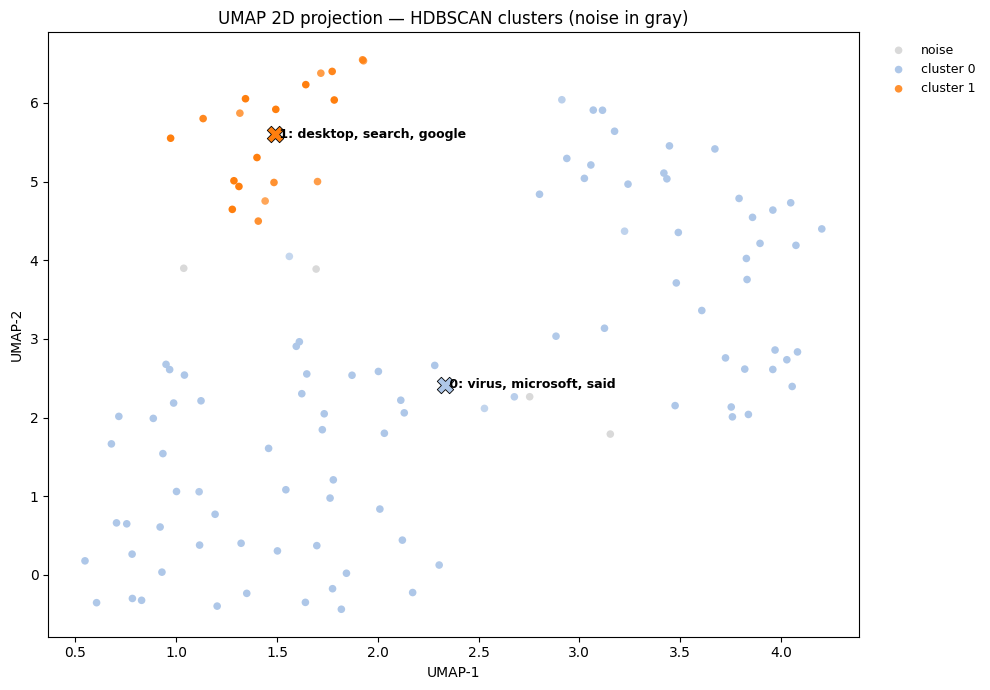

In [83]:
plt.rcParams["figure.dpi"] = 120
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 7))

df = sent_emb_df.copy().reset_index(drop=True)
xs = df["umap_x"].values
ys = df["umap_y"].values
labels = df["hdb_cluster"].values
probs = df["hdb_prob"].values

# Determine unique clusters and colors
unique_clusters = sorted(df["hdb_cluster"].unique())
# assign gray for noise (-1)
palette = plt.get_cmap("tab20")
cluster_colors = {c: (0,0,0) if c == -1 else palette(i % 50) for i, c in enumerate(unique_clusters)}

# Plot points: make high-prob points more opaque, low-prob more transparent
alphas = np.clip((probs - 0.2) / 0.8, 0.15, 1.0)  # scale prob->alpha (so low prob still visible)
for c in unique_clusters:
    mask = (labels == c)
    ax.scatter(xs[mask], ys[mask],
               s=30,
               alpha=alphas[mask],
               color=cluster_colors[c],
               label=("noise" if c == -1 else f"cluster {c}"),
               linewidths=0.2,
               edgecolors="none")

# Compute and plot centroids for non-noise clusters
non_noise = [c for c in unique_clusters if c != -1]
centroids = {}
for c in non_noise:
    mask = (labels == c)
    if mask.sum() == 0:
        continue
    cx = xs[mask].mean()
    cy = ys[mask].mean()
    centroids[c] = (cx, cy)
    ax.scatter(cx, cy, s=140, marker="X", color=cluster_colors[c], edgecolor="k", linewidth=0.6)

# Annotate centroid with cluster id and top keywords (if summary_df available)
if 'summary_df' in globals():
    for _, row in summary_df.iterrows():
        cid = row['cluster_id']
        if cid in centroids:
            cx, cy = centroids[cid]
            # take first 3 keywords for short label
            kw = row['top_keywords'].split(';')[:3] if isinstance(row['top_keywords'], str) else []
            ax.text(cx, cy, f" {cid}: " + ", ".join([k.strip() for k in kw]),
                    fontsize=9, fontweight='bold', verticalalignment='center')

ax.set_title("UMAP 2D projection — HDBSCAN clusters (noise in gray)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
